# Project - Airline AI Assistant

We'll now bring together what we've learned to make an AI Customer Support assistant for an Airline

In [1]:
# imports

import os
import json
from dotenv import load_dotenv
from openai import OpenAI
import gradio as gr
import sqlite3

import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..','..')))
from ai_tools import LLMQuery, handle_tool_call

In [2]:
system_message = """
You are a helpful assistant for an Airline called FlightAI.
Give short, courteous answers, no more than 1 sentence.
Always be accurate. If you don't know the answer, say so.
"""

In [3]:
DB = "prices.sqlite"
def get_ticket_price(destination_city):
    print(f"DATABASE TOOL CALLED: Getting price for {destination_city}", flush=True)
    with sqlite3.connect(DB) as conn:
        cursor = conn.cursor()
        cursor.execute('SELECT price FROM prices WHERE city = ?', (destination_city.lower(),))
        result = cursor.fetchone()
        return f"Ticket price to {destination_city} is ${result[0]}" if result else "No price data available for this city"

In [6]:
get_ticket_price("Paris")

DATABASE TOOL CALLED: Getting price for Paris


OperationalError: no such table: prices

In [ ]:
price_function = {
    "name": "get_ticket_price",
    "description": "Get the price of a return ticket to the destination city.",
    "parameters": {
        "type": "object",
        "properties": {
            "destination_city": {
                "type": "string",
                "description": "The city that the customer wants to travel to",
            },
        },
        "required": ["destination_city"],
        "additionalProperties": False
    }
}

generate_image_of_city_function = {
    "name": "artist",
    "description": "Generate an image of a city.",
    "parameters": {
        "type": "object",
        "properties": {
            "city": {
                "type": "string",
                "description": "The city of which the customer wants an image generated",
            },
        },
        "required": ["city"],
        "additionalProperties": False
    }
}

tools = [{"type": "function", "function": price_function}, {"type": "function", "function": generate_image_of_city_function}]
tools

[{'type': 'function',
  'function': {'name': 'get_ticket_price',
   'description': 'Get the price of a return ticket to the destination city.',
   'parameters': {'type': 'object',
    'properties': {'destination_city': {'type': 'string',
      'description': 'The city that the customer wants to travel to'}},
    'required': ['destination_city'],
    'additionalProperties': False}}},
 {'type': 'function',
  'function': {'name': 'artist',
   'description': 'Generate an image of a city.',
   'parameters': {'type': 'object',
    'properties': {'city': {'type': 'string',
      'description': 'The city of which the customer wants an image generated'}},
    'required': ['city'],
    'additionalProperties': False}}}]

## A bit more about what Gradio actually does:

1. Gradio constructs a frontend Svelte app based on our Python description of the UI
2. Gradio starts a server built upon the Starlette web framework listening on a free port that serves this React app
3. Gradio creates backend routes for our callbacks, like chat(), which calls our functions

And of course when Gradio generates the frontend app, it ensures that the the Submit button calls the right backend route.

That's it!

It's simple, and it has a result that feels magical.

# Let's go multi-modal!!

We can use DALL-E-3, the image generation model behind GPT-4o, to make us some images

Let's put this in a function called artist.

### Price alert: each time I generate an image it costs about 4 cents - don't go crazy with images!

In [5]:
# Some imports for handling images

import base64
from io import BytesIO
from PIL import Image

In [6]:
# Refactored client and artist function
def get_client():
    return LLMQuery(system_prompt=system_message, tools=tools, functions=[artist, get_ticket_price])

def artist(city):
    user_prompt = f"An image representing a vacation in {city}, showing tourist spots and everything unique about {city}, in a vibrant pop-art style"
    # Temporary client for image generation
    temp_client = LLMQuery(system_prompt="")
    image = temp_client.generate_image(user_prompt)
    return image


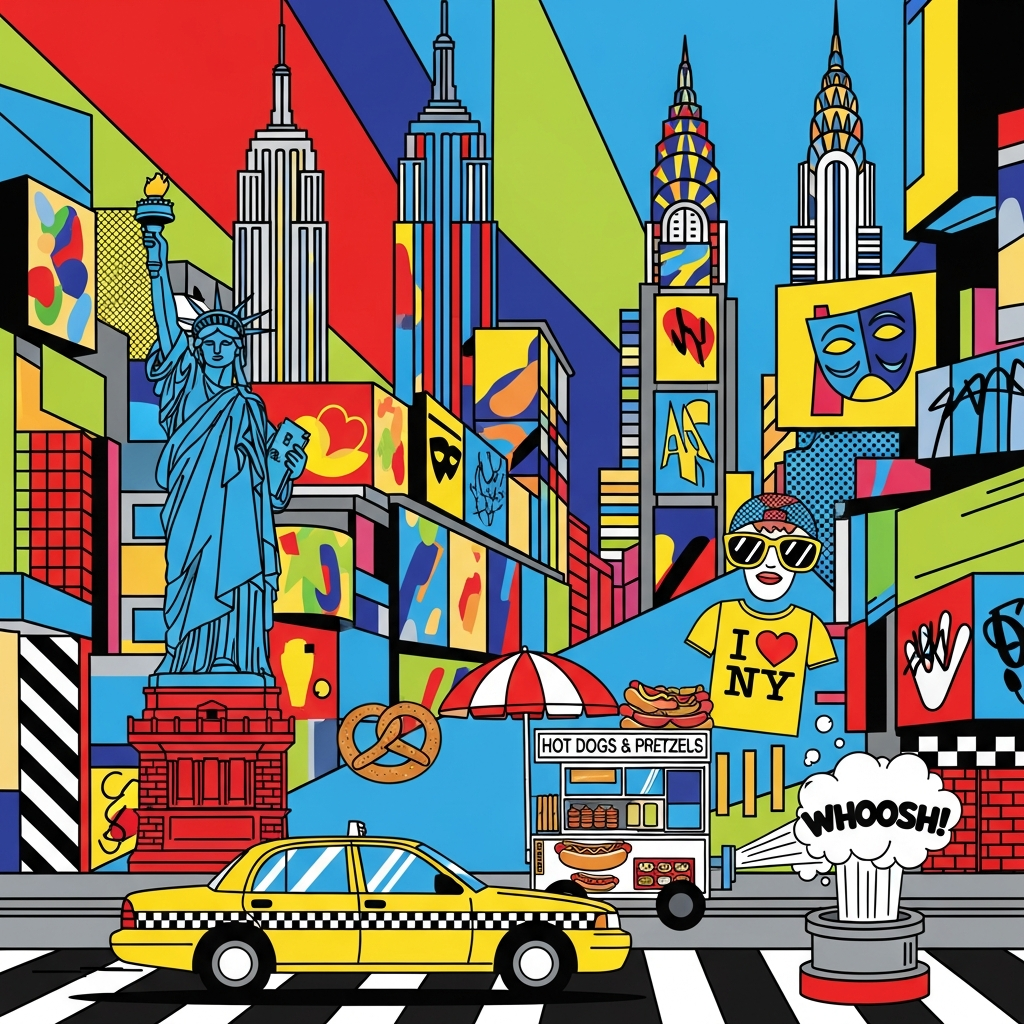

In [15]:
image = artist("New York City")
display(image)

In [7]:
def talker(message):
    talker_client = LLMQuery(system_prompt='Test')
    response = talker_client.generate_tts(message, voice="onyx")
    return response

In [17]:
# play tts message
from IPython.display import Audio
# Generate the audio data
audio_data = talker("This is a test message to verify audio playback.")
# Play the audio
Audio(audio_data)

## Let's bring this home:

1. A multi-modal AI assistant with image and audio generation
2. Tool callling with database lookup
3. A step towards an Agentic workflow


In [ ]:
# own implementation of LLMQuery




In [71]:
c, i = chat("Generate an Image for London")

In [80]:
client.chat_history

[]

## The 3 types of Gradio UI

`gr.Interface` is for standard, simple UIs

`gr.ChatInterface` is for standard ChatBot UIs

`gr.Blocks` is for custom UIs where you control the components and the callbacks

In [18]:
# Refactored Chat and UI with Client State
def chat(client, user_input):
    response = client.query(user_input)
    all_tool_responses = []
    while client.tool_calls:
        tool_response = handle_tool_call(client.tool_calls, functions=[artist, get_ticket_price])
        client.append_tool_result(tool_response)
        all_tool_responses.extend(tool_response)
        response = client.query()
    voice = talker(response)
    image = None
    for tr in all_tool_responses:
        if tr['name'] == 'artist':
            image = tr['output']
    chat_history_clean = [{"role":h["role"], "content":h["content"]} for h in client.chat_history if h["role"] in("assistant", "user") and h["content"]]
    return chat_history_clean, voice, image

def put_message_in_chatbot(message, client):
    chatbot_text = [{"role":h["role"], "content":h["content"]} for h in client.chat_history if h["role"] in("assistant", "user") and h["content"]] + [{"role":"user", "content":message}]
    print(chatbot_text)
    return "", chatbot_text, message

with gr.Blocks() as ui:
    client_state = gr.State(get_client)
    msg_state = gr.State()
    with gr.Row():
        chatbot = gr.Chatbot(height=500, type="messages")
        image_output = gr.Image(height=500, interactive=False)
    with gr.Row():
        audio_output = gr.Audio(autoplay=True)
    with gr.Row():
        message = gr.Textbox(label="Chat with our AI Assistant:")

    message.submit(put_message_in_chatbot, inputs=[message, client_state], outputs=[message, chatbot, msg_state]).then(
        chat, inputs=[client_state, msg_state], outputs=[chatbot, audio_output, image_output])

ui.launch(inbrowser=True)


* Running on local URL:  http://127.0.0.1:7870
* To create a public link, set `share=True` in `launch()`.


[{'role': 'user', 'content': 'Hi there'}]
[{'role': 'user', 'content': 'Hi there'}, {'role': 'assistant', 'content': 'Hello, how may I assist you with your travel plans today?'}, {'role': 'user', 'content': 'How much is a ticket to London?'}]
DATABASE TOOL CALLED: Getting price for London
[{'role': 'user', 'content': 'Hi there'}, {'role': 'assistant', 'content': 'Hello, how may I assist you with your travel plans today?'}, {'role': 'user', 'content': 'How much is a ticket to London?'}, {'role': 'assistant', 'content': 'The price of a return ticket to London is $799.0.'}, {'role': 'user', 'content': 'and to paris?'}]
DATABASE TOOL CALLED: Getting price for Paris
[{'role': 'user', 'content': 'Hi there'}, {'role': 'assistant', 'content': 'Hello, how may I assist you with your travel plans today?'}, {'role': 'user', 'content': 'How much is a ticket to London?'}, {'role': 'assistant', 'content': 'The price of a return ticket to London is $799.0.'}, {'role': 'user', 'content': 'and to paris?

# Exercises and Business Applications

Add in more tools - perhaps to simulate actually booking a flight. A student has done this and provided their example in the community contributions folder.

Next: take this and apply it to your business. Make a multi-modal AI assistant with tools that could carry out an activity for your work. A customer support assistant? New employee onboarding assistant? So many possibilities! Also, see the week2 end of week Exercise in the separate Notebook.

<table style="margin: 0; text-align: left;">
    <tr>
        <td style="width: 150px; height: 150px; vertical-align: middle;">
            <img src="../assets/thankyou.jpg" width="150" height="150" style="display: block;" />
        </td>
        <td>
            <h2 style="color:#090;">I have a special request for you</h2>
            <span style="color:#090;">
                My editor tells me that it makes a HUGE difference when students rate this course on Udemy - it's one of the main ways that Udemy decides whether to show it to others. If you're able to take a minute to rate this, I'd be so very grateful! And regardless - always please reach out to me at ed@edwarddonner.com if I can help at any point.
            </span>
        </td>
    </tr>
</table>